# Fase 4 — Baselines y protocolo de validación

Esta es, aunque no lo parezca, **la fase más importante del proyecto**. Aquí no buscamos todavía el
mejor modelo; construimos el **juez** que decidirá cuál es el mejor.

**El problema:** Kaggle no nos da las respuestas del test. Podemos subir predicciones (10 al día) y
ver el score... pero usar el leaderboard para probar ideas es (a) lentísimo y (b) peligroso: si
pruebas 30 ideas contra el mismo examen, acabarás "aprobando" por casualidad alguna que no funciona
(sobreajuste al leaderboard). Necesitamos un **juez interno, honesto y gratis**: la validación
cruzada.

**Las reglas se fijan ANTES de competir.** Definimos el protocolo ahora, con los baselines, y ya no
se toca: mismos folds, misma semilla, para todos los modelos de la Fase 5. Si cada modelo se midiera
con un protocolo distinto, las comparaciones no valdrían nada.

Plan de la fase:
1. Separar features (`X`) y target (`y`).
2. Ver **por qué** la accuracy sobre el propio train miente, y por qué un único split no basta.
3. Definir el protocolo: `StratifiedKFold` con k=5 y semilla fija.
4. Medir los dos baselines: regla del género y regresión logística.
5. Dejar montado el registro de experimentos.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

C_NO, C_SI, C_A, C_B = "#2a78d6", "#1baf7a", "#4a3aa7", "#eb6834"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": SECONDARY, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "Segoe UI", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.figsize": (7, 4),
})

datos = pd.read_csv("../data/processed/train_features.csv")
print(datos.shape)

(891, 19)


## 1 · Separar `X` e `y`

Convención universal en ML:

- **`X`** (mayúscula, es una matriz): las **features** — lo que el modelo puede mirar.
- **`y`** (minúscula, es un vector): el **target** — lo que debe predecir.

De la tabla de la Fase 3 hay que apartar dos columnas, como dejamos apuntado:

- `Survived` → es `y`. Dejarla en `X` sería darle al modelo la respuesta dentro del enunciado
  (accuracy 100%, utilidad 0%).
- `PassengerId` → fuera de ambas. Es un número de fila sin significado; pero si lo dejáramos, un
  árbol *encontraría* patrones espurios en él ("los ids 300-320 sobrevivieron mucho...") que no
  generalizan. Regla: **al modelo solo entra lo que tenga sentido que mire.**

In [2]:
X = datos.drop(columns=["PassengerId", "Survived"])
y = datos["Survived"]
print("X:", X.shape, "| y:", y.shape, "| tasa de supervivencia:", round(y.mean(), 4))

X: (891, 17) | y: (891,) | tasa de supervivencia: 0.3838


## 2 · ¿Con qué medimos si un modelo es bueno?

### Intento 1 (malo): accuracy sobre el propio train

Entrenar y medir sobre los mismos datos premia la **memorización**. Un modelo con capacidad
suficiente puede aprenderse los 891 pasajeros casi de memoria y clavar el train... sin haber
aprendido nada que sirva para pasajeros nuevos. Eso es **sobreajuste** (*overfitting*). Lo
demostraremos con números en la sección 6.

### Intento 2 (insuficiente): apartar un trozo como "mini-examen"

Idea razonable: entrenar con el 80% y medir en el 20% restante que el modelo no vio
(`train_test_split`). El problema con solo 891 filas: el resultado **depende de qué 179 pasajeros
caigan en el mini-examen**. Compruébalo — mismo modelo, misma proporción, solo cambia el barajado:

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

resultados = []
for semilla in range(10):
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, stratify=y, random_state=semilla)
    resultados.append(modelo.fit(X_tr, y_tr).score(X_va, y_va))

print("Accuracy con 10 barajados distintos:", [round(r, 3) for r in resultados])
print(f"Rango: {min(resultados):.3f} - {max(resultados):.3f}  (¡{(max(resultados)-min(resultados))*100:.0f} puntos de diferencia solo por azar!)")

Accuracy con 10 barajados distintos: [0.81, 0.838, 0.832, 0.849, 0.832, 0.86, 0.838, 0.81, 0.849, 0.838]
Rango: 0.810 - 0.860  (¡5 puntos de diferencia solo por azar!)


El **mismo modelo** saca entre 0.810 y 0.860 según la suerte del corte. Si comparásemos dos
modelos con un único split, una diferencia de 2-3 puntos podría ser puro ruido. Necesitamos algo
más estable.

### Intento 3 (el bueno): validación cruzada (*cross-validation*)

En vez de un mini-examen, hacemos **cinco**, aprovechando todos los datos:

```
Partimos el train en 5 trozos ("folds") iguales:   [ A ][ B ][ C ][ D ][ E ]

Ronda 1: entrena con B+C+D+E  → examina en A
Ronda 2: entrena con A+C+D+E  → examina en B
Ronda 3: entrena con A+B+D+E  → examina en C
Ronda 4: entrena con A+B+C+E  → examina en D
Ronda 5: entrena con A+B+C+D  → examina en E
```

Cada pasajero hace de examen **exactamente una vez**, y siempre para un modelo que no lo vio al
entrenar. Obtenemos 5 accuracies → informamos **media ± desviación típica**. La media es la
estimación honesta; la desviación nos dice cuánto baila (si dos modelos difieren menos que ese
baile, la diferencia no es concluyente).

Los tres apellidos de nuestro protocolo:

- **Estratificada** (`StratifiedKFold`): cada fold conserva la proporción 38/62 de
  supervivientes. Sin esto, un fold podría caer con 50% de supervivientes por azar y distorsionar.
- **`shuffle=True`**: baraja antes de partir, por si el CSV viene ordenado de alguna manera.
- **`random_state=42`**: fija el barajado → cualquiera que ejecute esto obtiene exactamente los
  mismos folds. Reproducibilidad.

¿Por qué k=5 y no 10 o 2? Es el equilibrio estándar: con k grande entrenas con más datos por ronda
pero pagas más cómputo y los mini-exámenes son diminutos; con k=5, cada examen tiene ~178 personas,
suficiente. El protocolo queda definido en [`src/validacion.py`](../src/validacion.py) junto a la
función `evaluar()` que usaremos para TODOS los modelos del proyecto.

In [4]:
import validacion

print("El juez del proyecto:", validacion.CV)

El juez del proyecto: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 3 · Baseline 0: los modelos "tontos"

Todo proyecto necesita un suelo. Dos referencias:

**(a) Clase mayoritaria** — "nadie sobrevive". Lo probamos con `DummyClassifier`, el generador de
baselines tontos de sklearn. Debería dar ≈ 0.616 (la proporción de muertos).

**(b) La regla del género** — "sobreviven exactamente las mujeres". Para evaluarla con el mismo
protocolo escribimos nuestro primer **estimador a medida**: en sklearn, un "modelo" es simplemente
un objeto con `.fit()` y `.predict()`. El nuestro no aprende nada (fit vacío) y predice copiando la
columna `IsFemale`. Que un "modelo" pueda ser una regla fija es una idea liberadora: los baselines
no necesitan ser sofisticados, solo honestos.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

class ReglaGenero(BaseEstimator, ClassifierMixin):
    """Predice Survived = IsFemale. Sin aprendizaje: es una regla fija."""
    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self
    def predict(self, X):
        return np.asarray(X["IsFemale"])

r_mayoria = validacion.evaluar(DummyClassifier(strategy="most_frequent"), X, y, "Mayoritaria (nadie vive)")
r_genero  = validacion.evaluar(ReglaGenero(), X, y, "Regla del genero")

Mayoritaria (nadie vive)       CV = 0.6162 ± 0.0023   (folds: 0.615 0.618 0.618 0.618 0.612)
Regla del genero               CV = 0.7868 ± 0.0188   (folds: 0.788 0.775 0.787 0.764 0.820)


Dos lecturas:

- La regla del género da **0.787 de CV** aquí, pero sabemos que en el leaderboard da **0.7655**.
  Esa diferencia de ~2 puntos es normal y conviene grabársela: nuestra CV estima el rendimiento en
  *pasajeros parecidos a los del train*; el test de Kaggle es otra muestra concreta de 418 personas,
  con su propio ruido. La CV ordena modelos de forma fiable; el número exacto del LB siempre vendrá
  con un desplazamiento.
- La desviación de la regla del género (±0.02) es puro ruido de muestreo — ni siquiera aprende nada
  y aun así sus folds bailan. Otro recordatorio de por qué un split único engaña.

## 4 · Baseline 1: regresión logística

Nuestro primer modelo de verdad. Intuición de cómo funciona (sin fórmulas de más):

1. Calcula una **puntuación** como suma ponderada de las features:
   `puntuacion = w1·IsFemale + w2·Pclass + ... + b`
2. Pasa esa puntuación por la **función sigmoide**, que la aplasta al rango (0, 1) → una
   **probabilidad** de sobrevivir. Si p > 0.5, predice 1.
3. "Entrenar" = encontrar los pesos `w` que mejor explican el train.

Es el modelo lineal clásico para clasificar: simple, rápido, interpretable (los pesos se pueden
leer, sección 5) — el baseline perfecto.

### Dos detalles de ingeniería que importan

**Escalado.** Nuestras features viven en rangos dispares: `Age` llega a 80, `IsFemale` es 0/1.
A la logística (que lleva **regularización**: una penalización anti-pesos-enormes que combate el
sobreajuste) los rangos dispares la despistan — penalizaría injustamente a las features de rango
pequeño. `StandardScaler` las pone a todas en la misma escala: media 0, desviación 1.

**Pipeline.** ¿Y dónde aprende el scaler sus medias? Si las calculara sobre TODO el train antes de
la CV, las medias del fold-examen se colarían en el entrenamiento — el mismo *leakage* de la Fase 2,
en miniatura. El **`Pipeline` de sklearn** encadena scaler → modelo como una sola pieza, y dentro de
la CV hace fit del scaler **solo con los folds de entrenamiento** de cada ronda, automáticamente.
Es la versión industrial del patrón `ajustar`/`transformar` que construimos a mano en la Fase 2 —
por eso lo construimos a mano primero.

In [6]:
logistica = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
r_logistica = validacion.evaluar(logistica, X, y, "Regresion logistica")

acc_train = logistica.fit(X, y).score(X, y)
print(f"\nAccuracy sobre el propio train: {acc_train:.4f}  (vs CV {r_logistica['media']:.4f} -> brecha minima: sano)")

Regresion logistica            CV = 0.8328 ± 0.0110   (folds: 0.838 0.826 0.815 0.843 0.843)



Accuracy sobre el propio train: 0.8350  (vs CV 0.8328 -> brecha minima: sano)


**0.833 ± 0.011.** El baseline serio queda fijado — y fíjate que ya supera con margen a la regla
del género (0.787): las features de las Fases 2-3 están trabajando. Además, train accuracy (0.835) ≈
CV (0.833): el modelo no está memorizando.

## 5 · Bonus del modelo lineal: leer sus pesos

Los coeficientes `w` dicen hacia dónde empuja cada feature (tras el escalado, sus magnitudes son
comparables entre sí). Signo positivo → empuja hacia "sobrevive"; negativo → hacia "no".

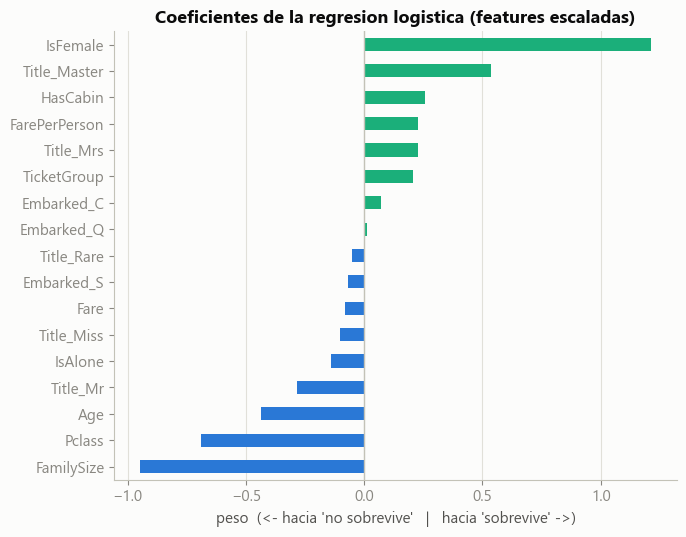

In [7]:
coefs = pd.Series(logistica[-1].coef_[0], index=X.columns).sort_values()
ax = coefs.plot(kind="barh", color=[(C_NO if v < 0 else C_SI) for v in coefs], figsize=(7, 5.5))
ax.set_title("Coeficientes de la regresion logistica (features escaladas)")
ax.set_xlabel("peso  (<- hacia 'no sobrevive'   |   hacia 'sobrevive' ->)")
ax.axvline(0, color=BASELINE, linewidth=1)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Lecturas que cuadran con todo el EDA: `IsFemale` (+1.21) domina, `Title_Master` (+0.54) rescata
a los niños, `Pclass` y `Age` empujan en contra.

**¿Y por qué `Title_Miss` sale ligeramente negativa, si en la Fase 3 correlacionaba +0.33 con
sobrevivir?** Gran pregunta, y la lección más sutil del notebook: un coeficiente mide el efecto de
una feature **manteniendo las demás fijas**. El "ser mujer" de las Miss ya lo cobra `IsFemale`; el
coeficiente de `Title_Miss` solo recoge lo que queda *después* — y condicionado a ser mujer, ser
Miss (soltera, más de 3ª clase, viajando sola) era ligeramente peor que ser Mrs. Los coeficientes
**no** son correlaciones: son efectos condicionales, y con features correlacionadas entre sí
(`FamilySize`/`TicketGroup`/`IsAlone`) se reparten el crédito de formas poco intuitivas.

## 6 · La demostración prometida: el sobreajuste en vivo

Un árbol de decisión sin límite de profundidad puede crear una regla para casi cada pasajero —
memoria pura. Miremos su train accuracy y su CV:

In [8]:
from sklearn.tree import DecisionTreeClassifier

arbol_libre = DecisionTreeClassifier(random_state=42)
r_arbol = validacion.evaluar(arbol_libre, X, y, "Arbol sin limite")
acc_train_arbol = arbol_libre.fit(X, y).score(X, y)
print(f"\nAccuracy sobre el propio train: {acc_train_arbol:.4f}")
print(f"Brecha train-CV: {(acc_train_arbol - r_arbol['media'])*100:.1f} puntos <- ESTO es sobreajuste")

Arbol sin limite               CV = 0.8081 ± 0.0133   (folds: 0.827 0.820 0.798 0.792 0.803)

Accuracy sobre el propio train: 0.9877
Brecha train-CV: 18.0 puntos <- ESTO es sobreajuste


**98.8% en train, 80.8% en CV** — 18 puntos de espejismo. El árbol se sabe el train de memoria
(esas 11 filas que no clava son probablemente pasajeros idénticos en features con destinos
distintos), pero ante pasajeros nuevos rinde *peor* que la humilde logística. Moraleja doble:

1. La accuracy de train no se usa **jamás** para juzgar un modelo.
2. Más capacidad ≠ más acierto. En la Fase 5, la gracia de Random Forest y Gradient Boosting será
   justamente domar árboles con trucos que controlan la memorización.

## 7 · El registro de experimentos

Última pieza de infraestructura: una tabla donde anotar **cada** experimento (qué features, qué
modelo, qué CV dio, y — cuando subamos a Kaggle — qué LB). Sin registro, en dos días no recordarás
si la idea X ayudó o estorbó. La guardamos en `submissions/registro_experimentos.csv`.

In [9]:
registro = pd.DataFrame([
    {"version": "base-mayoria",  "fecha": "2026-07-08", "features": "-",              "modelo": "DummyClassifier(most_frequent)",  "cv_media": round(r_mayoria["media"], 4),   "cv_std": round(r_mayoria["std"], 4),   "lb_publico": None},
    {"version": "base-genero",   "fecha": "2026-07-08", "features": "IsFemale",       "modelo": "ReglaGenero",                     "cv_media": round(r_genero["media"], 4),    "cv_std": round(r_genero["std"], 4),    "lb_publico": 0.7655},
    {"version": "v01-logistica", "fecha": "2026-07-08", "features": "16 (Fase 3)",    "modelo": "StandardScaler+LogisticRegression", "cv_media": round(r_logistica["media"], 4), "cv_std": round(r_logistica["std"], 4), "lb_publico": None},
])
registro.to_csv("../submissions/registro_experimentos.csv", index=False)
registro

,version,fecha,features,modelo,cv_media,cv_std,lb_publico
0,base-mayoria,2026-07-08,-,DummyClassifier(most_frequent),0.6162,0.0023,NaN
1,base-genero,2026-07-08,IsFemale,ReglaGenero,0.7868,0.0188,0.7655
2,v01-logistica,2026-07-08,16 (Fase 3),StandardScaler+LogisticRegression,0.8328,0.0110,NaN


(El 0.7655 de la regla del género es público y conocido — es el score del `gender_submission.csv`
que regala Kaggle. Los demás LB los iremos rellenando cuando subamos submissions en la Fase 6.)

## 8 · Conclusiones de la Fase 4

- **El juez quedó fijado**: `StratifiedKFold(5, shuffle, seed=42)` en `src/validacion.py`. Ya no se
  toca; todos los modelos de la Fase 5 pasan por `validacion.evaluar()`.
- **Suelo y listón**: mayoritaria 0.616 · regla del género 0.787 (LB real 0.7655) ·
  **logística 0.833 ± 0.011** ← el número a batir.
- Vimos con números por qué la accuracy de train miente (árbol: 98.8% train / 80.8% CV), por qué un
  split único es ruleta (0.81-0.86 según la semilla), y cómo el `Pipeline` mete el escalado dentro
  de la CV sin leakage.
- Bonus: aprendimos a leer coeficientes como efectos *condicionales*, no correlaciones.

**Siguiente — Fase 5:** el torneo. Random Forest, Gradient Boosting (XGBoost/LightGBM), SVM y KNN
contra la logística, todos con el mismo juez; ajuste de hiperparámetros de los finalistas y análisis
de errores (¿a quién seguimos fallando?).